In [6]:
pip install pandas numpy matplotlib seaborn scikit-learn streamlit

## LOADING THE DATA

In [7]:
import pandas as pd

df = pd.read_csv(
    "/content/HYDWeatherData.csv",
    skiprows=14
)
print(df.head())
print(df.info())

         PARAMETER  YEAR    JAN    FEB    MAR    APR    MAY     JUN     JUL  \
0  PRECTOTCORR_SUM  2000   0.00  59.74   0.56   0.61  48.35  249.02   82.07   
1  PRECTOTCORR_SUM  2001   7.52   0.00  39.19  24.67   3.19  187.80   60.58   
2  PRECTOTCORR_SUM  2002  15.18   0.95  11.31   2.05  66.40  156.88   76.18   
3  PRECTOTCORR_SUM  2003   0.12   6.10  10.97  23.19   1.35   73.92  258.93   
4  PRECTOTCORR_SUM  2004  34.04   5.47  21.13  54.33  43.67   35.63  227.64   

      AUG     SEP     OCT   NOV   DEC     ANN  
0  403.28   58.23   27.21  4.94  0.75  934.76  
1  220.88  127.66  114.95  2.58  0.62  789.64  
2  216.13   36.16  105.23  2.58  0.98  690.03  
3  155.26   66.12  148.61  0.87  4.99  750.43  
4   64.69  118.55   74.05  1.34  0.00  680.54  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PARAMETER  156 non-null    object 
 1   YEAR   

## MELTING THE DATA

In [8]:
df_long = df.melt(
    id_vars=['PARAMETER', 'YEAR'],
    value_vars=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],
    var_name='Month',
    value_name='Precipitation'
)
df_long

,PARAMETER,YEAR,Month,Precipitation
0,PRECTOTCORR_SUM,2000,JAN,0.00
1,PRECTOTCORR_SUM,2001,JAN,7.52
2,PRECTOTCORR_SUM,2002,JAN,15.18
3,PRECTOTCORR_SUM,2003,JAN,0.12
4,PRECTOTCORR_SUM,2004,JAN,34.04
...,...,...,...,...
1867,WS2M,2021,DEC,1.53
1868,WS2M,2022,DEC,1.61
1869,WS2M,2023,DEC,1.97
1870,WS2M,2024,DEC,1.96


In [9]:
month_map = {
    'JAN':1, 'FEB':2, 'MAR':3, 'APR':4,
    'MAY':5, 'JUN':6, 'JUL':7, 'AUG':8,
    'SEP':9, 'OCT':10, 'NOV':11, 'DEC':12
}

df_long['Month'] = df_long['Month'].map(month_map)
df_long

,PARAMETER,YEAR,Month,Precipitation
0,PRECTOTCORR_SUM,2000,1,0.00
1,PRECTOTCORR_SUM,2001,1,7.52
2,PRECTOTCORR_SUM,2002,1,15.18
3,PRECTOTCORR_SUM,2003,1,0.12
4,PRECTOTCORR_SUM,2004,1,34.04
...,...,...,...,...
1867,WS2M,2021,12,1.53
1868,WS2M,2022,12,1.61
1869,WS2M,2023,12,1.97
1870,WS2M,2024,12,1.96


In [10]:
df_long['Date'] = pd.to_datetime(df_long[['YEAR', 'Month']].assign(DAY=1))
df_long

,PARAMETER,YEAR,Month,Precipitation,Date
0,PRECTOTCORR_SUM,2000,1,0.00,2000-01-01
1,PRECTOTCORR_SUM,2001,1,7.52,2001-01-01
2,PRECTOTCORR_SUM,2002,1,15.18,2002-01-01
3,PRECTOTCORR_SUM,2003,1,0.12,2003-01-01
4,PRECTOTCORR_SUM,2004,1,34.04,2004-01-01
...,...,...,...,...,...
1867,WS2M,2021,12,1.53,2021-12-01
1868,WS2M,2022,12,1.61,2022-12-01
1869,WS2M,2023,12,1.97,2023-12-01
1870,WS2M,2024,12,1.96,2024-12-01


## PRINTING RAIN STATS

In [11]:
rain_df = df[df['PARAMETER'] == 'PRECTOTCORR_SUM']
print(rain_df)

          PARAMETER  YEAR    JAN    FEB     MAR    APR     MAY     JUN  \
0   PRECTOTCORR_SUM  2000   0.00  59.74    0.56   0.61   48.35  249.02   
1   PRECTOTCORR_SUM  2001   7.52   0.00   39.19  24.67    3.19  187.80   
2   PRECTOTCORR_SUM  2002  15.18   0.95   11.31   2.05   66.40  156.88   
3   PRECTOTCORR_SUM  2003   0.12   6.10   10.97  23.19    1.35   73.92   
4   PRECTOTCORR_SUM  2004  34.04   5.47   21.13  54.33   43.67   35.63   
5   PRECTOTCORR_SUM  2005  39.93   1.48   14.05  24.06   30.02  103.73   
6   PRECTOTCORR_SUM  2006   0.00   0.00   41.62  59.24   89.74   94.14   
7   PRECTOTCORR_SUM  2007   0.00   0.25    0.00  20.49   18.05  167.17   
8   PRECTOTCORR_SUM  2008   0.29  48.98  153.28  11.50   16.37   55.97   
9   PRECTOTCORR_SUM  2009   0.00   0.00    4.12  19.15   32.12   81.24   
10  PRECTOTCORR_SUM  2010   7.23   6.38    0.06   3.01   22.86  128.34   
11  PRECTOTCORR_SUM  2011   0.05   6.00    2.00   4.83   10.23   48.38   
12  PRECTOTCORR_SUM  2012   2.57   0.0

In [12]:
df_long = df_long.sort_values('Date')
print(df_long.head())

           PARAMETER  YEAR  Month  Precipitation       Date
0    PRECTOTCORR_SUM  2000      1           0.00 2000-01-01
78                TS  2000      1          23.83 2000-01-01
104            WD10M  2000      1          98.60 2000-01-01
130             WS2M  2000      1           1.93 2000-01-01
52               T2M  2000      1          22.80 2000-01-01


## RAINFALL TREND OVERTIME

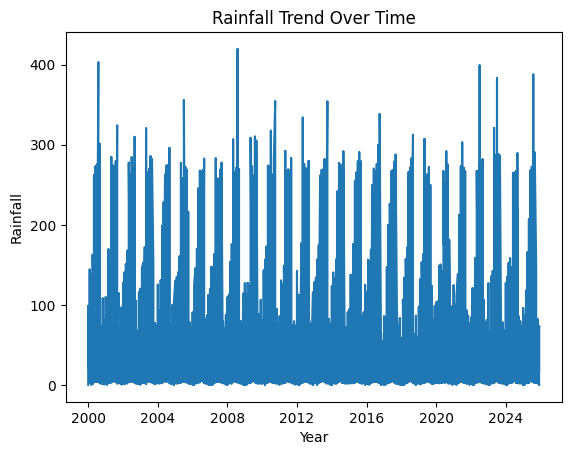

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_long['Date'], df_long['Precipitation'])
plt.title("Rainfall Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.show()

# INSIGHTS
--> Rainfall exhibits significant fluctuations throughout the period from 2000 to 2025.

--> There is no consistent long-term increasing or decreasing trend.

--> The pattern is dominated by irregular ups and downs, indicating variability in yearly rainfall behavior.



## AVG MONTHY PRECIPITATION

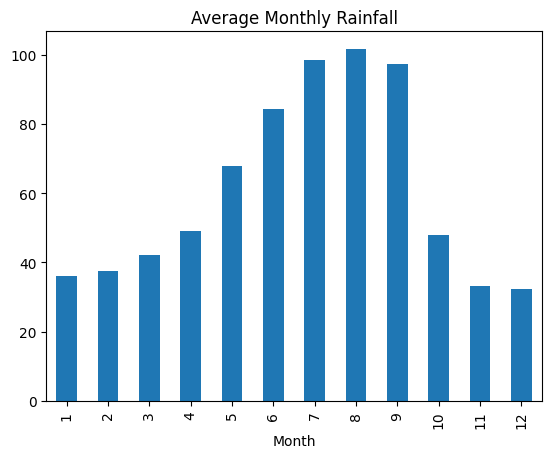

In [14]:
monthly_avg = df_long.groupby('Month')['Precipitation'].mean()

plt.figure()
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Rainfall")
plt.show()

INSIGHTS

--> August records the highest average rainfall, making it the peak monsoon month.

--> December shows the lowest rainfall, indicating dry winter conditions.

--> Rainfall is highly seasonal, with most precipitation concentrated in a few months.

YEARLY RAINFALL TREND

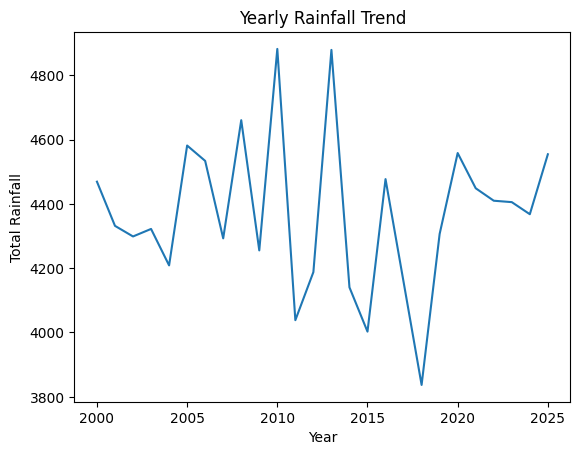

In [15]:
yearly = df_long.groupby('YEAR')['Precipitation'].sum()

plt.figure()
plt.plot(yearly.index, yearly.values)
plt.title("Yearly Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Total Rainfall")
plt.show()

INSIGHTS

--> The average annual rainfall ranges approximately between 4400 mm and 4600 mm.

--> The years 2012–2014 experienced unusually high rainfall, indicating unseasonal or excess precipitation.

--> The period from 2010 to 2019 shows strong variability with frequent ups and downs.

--> A gradual increasing trend in annual rainfall is observed after 2019.

## MONSOON RAINS TREND

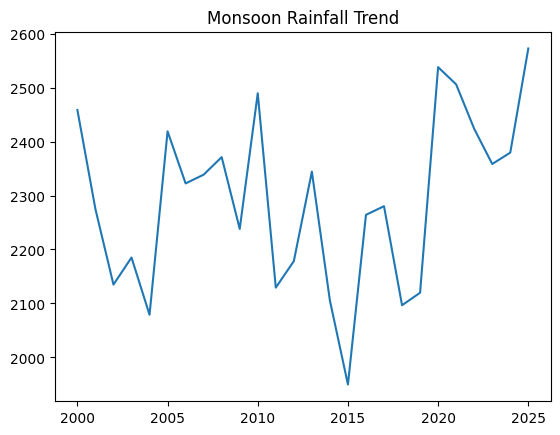

In [16]:
monsoon = df_long[df_long['Month'].isin([6,7,8,9])]
monsoon_yearly = monsoon.groupby('YEAR')['Precipitation'].sum()

plt.figure()
plt.plot(monsoon_yearly.index, monsoon_yearly.values)
plt.title("Monsoon Rainfall Trend")
plt.show()

INSIGHTS

--> Monsoon rainfall shows significant fluctuations over the past 25 years, indicating variability in seasonal precipitation.

--> The periods 2013–2014 and 2017–2018 experienced relatively deficit rainfall, suggesting weaker monsoon performance during those years.

--> From 2019 onwards, a noticeable increasing trend is observed, with consistently better monsoon rainfall in recent years.

This shift after 2019 may indicate a strengthening of monsoon activity or changing climatic patterns in recent years.

<Axes: xlabel='Season'>

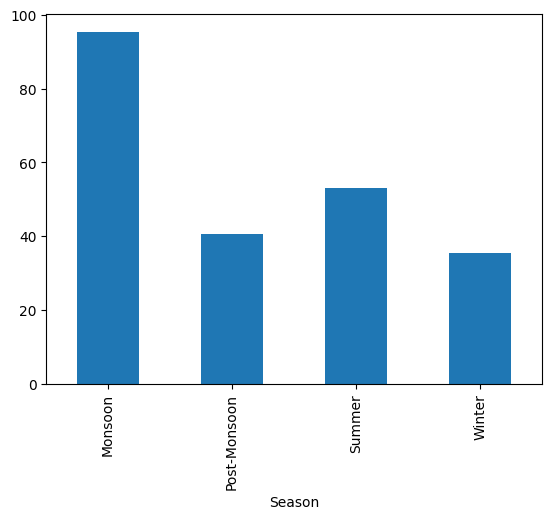

In [17]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8,9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df_long['Season'] = df_long['Month'].apply(get_season)

seasonal = df_long.groupby('Season')['Precipitation'].mean()

seasonal.plot(kind='bar')

## WETTER AND DRIER YEARS

In [18]:
wettest = yearly.idxmax()
driest = yearly.idxmin()

print("Wettest Year:", wettest)
print("Driest Year:", driest)

Wettest Year: 2010
Driest Year: 2018


## RAINS VARIABILITY

In [19]:
print("Standard Deviation:", yearly.std())

Standard Deviation: 244.51537825226077


## TOP 10 RAINIEST YEARS

In [20]:
top10 = yearly.sort_values(ascending=False).head(10)
print(top10)

YEAR
2010    4881.92
2013    4878.89
2008    4660.28
2005    4581.47
2020    4558.11
2025    4554.28
2006    4533.69
2016    4477.01
2000    4469.02
2021    4448.53
Name: Precipitation, dtype: float64


## PREDICTION MODEL

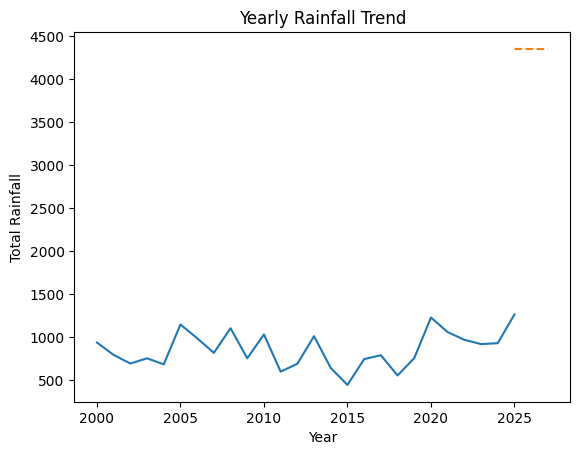

/tmp/ipykernel_3268/1670837197.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


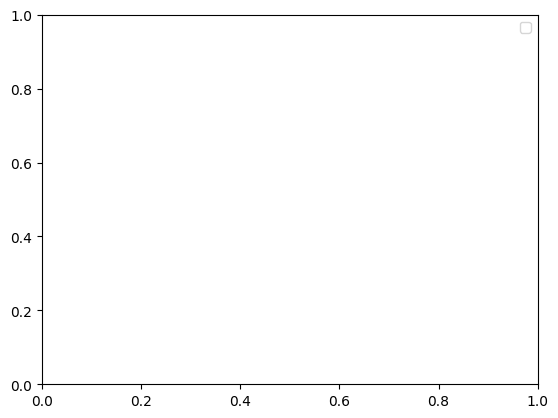

In [27]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(yearly.index, yearly.values, label = 'Actual')

plt.plot(future_years.flatten(), predictions, linestyle='dashed', label='Predicted')

plt.title("Yearly Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Total Rainfall")
plt.show()
plt.legend()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X = df_long[['YEAR']]          # Independent variable (using YEAR from df_long)
y = df_long['Precipitation']     # Dependent variable (using Precipitation from df_long)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("\n===== Model Evaluation Metrics ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


===== Model Evaluation Metrics ===
Mean Absolute Error (MAE): 55.2968
Mean Squared Error (MSE): 6150.3760
Root Mean Squared Error (RMSE): 78.4243
R² Score: -0.0012


In [23]:
print(df.head())
print(df.columns)

         PARAMETER  YEAR    JAN    FEB    MAR    APR    MAY     JUN     JUL  \
0  PRECTOTCORR_SUM  2000   0.00  59.74   0.56   0.61  48.35  249.02   82.07   
1  PRECTOTCORR_SUM  2001   7.52   0.00  39.19  24.67   3.19  187.80   60.58   
2  PRECTOTCORR_SUM  2002  15.18   0.95  11.31   2.05  66.40  156.88   76.18   
3  PRECTOTCORR_SUM  2003   0.12   6.10  10.97  23.19   1.35   73.92  258.93   
4  PRECTOTCORR_SUM  2004  34.04   5.47  21.13  54.33  43.67   35.63  227.64   

      AUG     SEP     OCT   NOV   DEC     ANN  
0  403.28   58.23   27.21  4.94  0.75  934.76  
1  220.88  127.66  114.95  2.58  0.62  789.64  
2  216.13   36.16  105.23  2.58  0.98  690.03  
3  155.26   66.12  148.61  0.87  4.99  750.43  
4   64.69  118.55   74.05  1.34  0.00  680.54  
Index(['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN'],
      dtype='object')


In [24]:
yearly = df[df['PARAMETER'] == 'PRECTOTCORR_SUM'].set_index('YEAR')['ANN']
print(yearly.head())

YEAR
2000    934.76
2001    789.64
2002    690.03
2003    750.43
2004    680.54
Name: ANN, dtype: float64
